# Product Category Clustering — TF-IDF + KMeans
Goal: group products into categories/clusters based on their name and sub-categories, using TF-IDF features and KMeans.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib 

sns.set_style("whitegrid")

## 2. Load data
Clustering works on **one row per product**, not one row per review. If your raw data is one row per review, we aggregate all review text per product below.

Update the path/column names to match your dataset.

In [2]:
RAW_CSV_PATH = "../data/processed/combined_cleaned_full.csv"
df = pd.read_csv(RAW_CSV_PATH)
print(df.shape)
df = df.dropna(subset='clean_text', ignore_index=True)
print(df.shape)
#print('Missing values:', df.isna().sum())
df.head()

(30744, 10)
(30741, 10)


,asins,categories,id,name,primaryCategories,reviews.rating,reviews.text,reviews.title,clean_text,label
0,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,3,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,i order 3 of them and one of the item is bad q...,neutral
1,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,4,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,bulk is always the less expensive way to go fo...,positive
2,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,well they are not duracell but for the price i...,positive
3,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,seem to work as well as name brand batteries a...,positive
4,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,these batteries are very long lasting the pric...,positive


## 3. Aggregate products by product name

In [3]:
product_docs = (
    df.groupby('name')
      .agg(
          categories=('categories', lambda x: ' '.join(set(x))),
          primaryCategories=('primaryCategories', lambda x: ' '.join(set(x))))
      .sort_values(by='name', ascending=False)
      .reset_index()
)
product_docs['combined_text'] = product_docs['name'] + "," + product_docs['categories']

print("Number of unique products:", product_docs.shape[0])
product_docs.head()

Number of unique products: 79


,name,categories,primaryCategories,combined_text
0,Two Door Top Load Pet Kennel Travel Crate Dog ...,"Carriers & Totes,Hard-Sided Carriers,Crates Ke...",Animals & Pet Supplies,Two Door Top Load Pet Kennel Travel Crate Dog ...
1,Oem Amazon Kindle Power Usb Adapter Wall Trave...,"Tablet & eBook Reader Accs,Consumer Electronic...",Electronics,Oem Amazon Kindle Power Usb Adapter Wall Trave...
2,"Kindle Voyage E-reader, 6 High-Resolution Disp...","eBook Readers,Electronics Features,Walmart for...",Electronics,"Kindle Voyage E-reader, 6 High-Resolution Disp..."
3,"Kindle Voyage E-reader, 6 High-Resolution Disp...","eBook Readers,E-Readers & Accessories,Amazon B...","Electronics,Media","Kindle Voyage E-reader, 6 High-Resolution Disp..."
4,Kindle PowerFast International Charging Kit (f...,"Chargers & Adapters,Computers & Accessories,Fi...",Electronics,Kindle PowerFast International Charging Kit (f...


## 4. TF-IDF vectorization

In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,
    #min_df=5,
    #max_df=0.8,
    stop_words="english",
    ngram_range=(1, 2),
)

X_tfidf = tfidf.fit_transform(product_docs["combined_text"])
print("TF-IDF matrix shape:", X_tfidf.shape)
tfidf

TF-IDF matrix shape: (79, 1590)


,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'


## 6. Find a good number of clusters (k)

In [5]:
k_range = range(3, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_tfidf, labels))
    #print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_scores[-1]:.3f}")

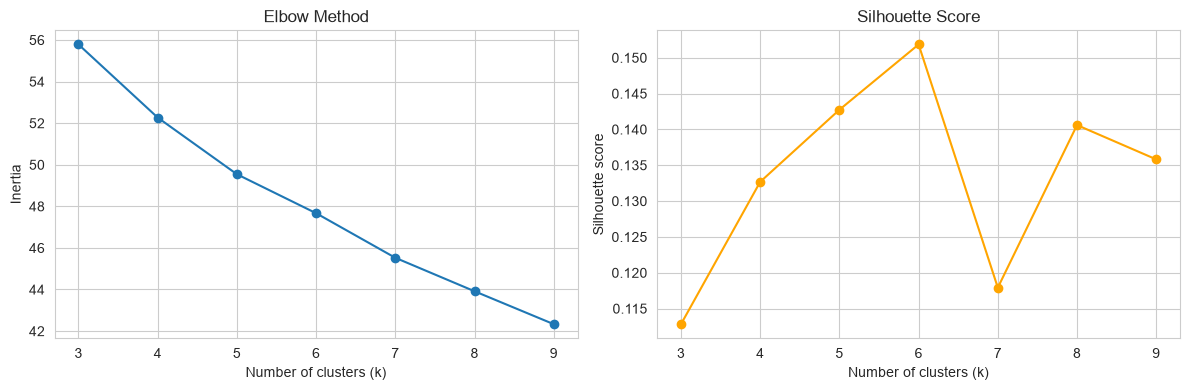

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

## 7. Fit the final KMeans model


In [7]:
FINAL_K = 6   # 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
product_docs["cluster"] = kmeans.fit_predict(X_tfidf)

#product_docs["cluster"].value_counts().sort_index()

# Compare with k=5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
product_docs["cluster_k5"] = kmeans_5.fit_predict(X_tfidf)
#product_docs["cluster_k5"].value_counts().sort_index()

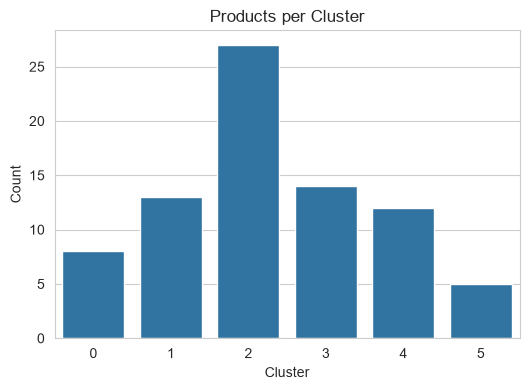

In [8]:
# Plot cluster size distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=product_docs["cluster"])
plt.title("Products per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## 8. Inspect clusters — top terms per cluster

In [9]:
feature_names = np.array(tfidf.get_feature_names_out())
top_n = 30

for cluster_id in sorted(product_docs["cluster"].unique()):
    center = kmeans.cluster_centers_[cluster_id]
    top_term_indices = center.argsort()[::-1][:top_n]
    top_terms = feature_names[top_term_indices]
    print(f"Cluster {cluster_id} ({(product_docs['cluster'] == cluster_id).sum()} products):")
    print("  ", ", ".join(top_terms))
    print()

Cluster 0 (8 products):
   supplies, pet, batteries, health, household, crates, dog, office, cat, file, supplies pet, products, crate, pet supplies, stands, kennels, crates kennels, door, litter, expanding, pet products, camera, health household, care, amazonbasics, cat supplies, metal dog, folding metal, metal, door folding

Cluster 1 (13 products):
   readers, kindle, reader, tablets, amazon, kindle readers, readers readers, readers accessories, wi fi, fi, wi, ebook readers, fi includes, ebook, amazon ereaders, ereaders, 300, display 300, high, ppi, resolution, high resolution, resolution display, 300 ppi, reader computers, book reader, book, amazon book, kindle voyage, voyage

Cluster 2 (27 products):
   tablets, tablets tablets, hd, tablets computers, computers tablets, computers, amazon tablets, gb, tablet, display, hd display, hd tablet, tablets amazon, offers, special offers, special, amazon, 16 gb, 16, new hd, tablets electronics, display wi, new, tablet hd, tablet alexa, reade

In [10]:
# Check for k=5
for cluster_id in sorted(product_docs["cluster_k5"].unique()):
    center = kmeans_5.cluster_centers_[cluster_id]
    top_term_indices = center.argsort()[::-1][:top_n]
    top_terms = feature_names[top_term_indices]
    print(f"Cluster {cluster_id} ({(product_docs['cluster'] == cluster_id).sum()} products):")
    print("  ", ", ".join(top_terms))
    print()

Cluster 0 (8 products):
   tablets, tablets tablets, hd, tablets computers, computers tablets, computers, amazon tablets, gb, tablet, display, hd display, hd tablet, offers, special, special offers, tablets amazon, 16 gb, 16, amazon, new hd, display wi, tablets electronics, new, tablet hd, tablet alexa, gb includes, 32, 32 gb, alexa, offers tablets

Cluster 1 (13 products):
   tv, video, media, streaming, audio, streaming media, tv video, home, electronics, media players, players, kitchen, amazon tv, audio video, home audio, amazon smp, smp, amazon, alexa voice, voice remote, remote, electronics tv, tvs, devices, video home, digital, dvd, tv alexa, consumer electronics, consumer

Cluster 2 (27 products):
   home, smart, speakers, echo, amazon echo, amazon, smart home, electronics, smart speakers, amazon home, audio, assistants, assistant, voice, hubs, device, digital device, digital, bluetooth, home automation, automation, hub, wireless, consumer, consumer electronics, assistants amazo

## 9. Look at a few example products per cluster
Reading a couple of raw documents per cluster is the fastest sanity check that the clusters make sense.

In [11]:
for cluster_id in sorted(product_docs["cluster"].unique()):
    print(f"--- Cluster {cluster_id} ---")
    sample = product_docs[product_docs["cluster"] == cluster_id].sample(
        min(3, (product_docs["cluster"] == cluster_id).sum()), random_state=1
    )
    for _, row in sample.iterrows():
        print(row["combined_text"][:200], "...")
    print()

--- Cluster 0 ---
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary,AA,AAA,Electronics Features,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household  ...
Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet,Standard Litter Boxes,Litter Boxes,Cat Supplies,Pet Supplies,Top Cat Supplies,Pet Products ...
Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size,Office,File Jackets & File Pockets,File Folders & Accessories,Files & Supplies,Office Solutions,Office Supplies,Office P ...

--- Cluster 1 ---
Kindle Oasis E-reader with Leather Charging Cover - Walnut, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,E-Readers & Accessories,EBook Readers,Amazon Book Reader,Computers & Ta ...
Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers,eBook Readers,E-Readers & Accessories,Amazon Bo

In [12]:
product_docs[product_docs["cluster"] == 0]

,name,categories,primaryCategories,combined_text,cluster,cluster_k5
0,Two Door Top Load Pet Kennel Travel Crate Dog ...,"Carriers & Totes,Hard-Sided Carriers,Crates Ke...",Animals & Pet Supplies,Two Door Top Load Pet Kennel Travel Crate Dog ...,0,4
22,Expanding Accordion File Folder Plastic Portab...,"Office,File Jackets & File Pockets,File Folder...",Office Supplies,Expanding Accordion File Folder Plastic Portab...,0,4
27,Cat Litter Box Covered Tray Kitten Extra Large...,"Standard Litter Boxes,Litter Boxes,Cat Supplie...",Animals & Pet Supplies,Cat Litter Box Covered Tray Kitten Extra Large...,0,4
29,AmazonBasics Ventilated Adjustable Laptop Stand,"Laptop Computer Stands,Electronics Features,St...",Electronics,AmazonBasics Ventilated Adjustable Laptop Stan...,0,4
31,AmazonBasics Single-Door Folding Metal Dog Cra...,"Crate Training,Crates Kennels,Pet Supplies,Why...",Animals & Pet Supplies,AmazonBasics Single-Door Folding Metal Dog Cra...,0,4
36,AmazonBasics Double-Door Folding Metal Dog Cra...,"Crate Training,Crates Kennels,Pet Supplies,Dog...",Animals & Pet Supplies,AmazonBasics Double-Door Folding Metal Dog Cra...,0,4
39,AmazonBasics AAA Performance Alkaline Batterie...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,AmazonBasics AAA Performance Alkaline Batterie...,0,4
40,AmazonBasics AA Performance Alkaline Batteries...,"AA,AAA,Electronics Features,Health,Electronics...",Health & Beauty,AmazonBasics AA Performance Alkaline Batteries...,0,4


In [13]:
product_docs[product_docs["cluster"] == 3]

,name,categories,primaryCategories,combined_text,cluster,cluster_k5
23,Echo Spot Pair Kit (Black),"Amazon Echo,Networking,Home & Tools,Smart Home...",Electronics,"Echo Spot Pair Kit (Black),Amazon Echo,Network...",3,2
24,Echo Dot (Previous generation),"Consumer Electronics,Amazon Echo,Electronics F...",Electronics,"Echo Dot (Previous generation),Consumer Electr...",3,2
26,Certified Refurbished Amazon Echo,"Consumer Electronics,Amazon Echo,Smart Speaker...",Electronics,"Certified Refurbished Amazon Echo,Consumer Ele...",3,2
32,AmazonBasics Silicone Hot Handle Cover/Holder ...,"Home & Garden,Oven Mitts & Potholders,Kitchen,...",Home & Garden,AmazonBasics Silicone Hot Handle Cover/Holder ...,3,1
34,AmazonBasics Nespresso Pod Storage Drawer - 50...,"Home & Garden,Kitchen Storage & Organization,K...",Home & Garden,AmazonBasics Nespresso Pod Storage Drawer - 50...,3,4
44,Amazon Tap Smart Assistant Alexaenabled (black...,"Amazon Echo,Home Theater & Audio,MP3 MP4 Playe...",Electronics,Amazon Tap Smart Assistant Alexaenabled (black...,3,2
45,Amazon Tap - Alexa-Enabled Portable Bluetooth ...,"Amazon Echo,Home Theater & Audio,MP3 MP4 Playe...",Electronics,Amazon Tap - Alexa-Enabled Portable Bluetooth ...,3,2
52,Amazon Echo ‚Äì White,"Stereos,Remote Controls,Audio Docks & Mini Spe...",Electronics,"Amazon Echo ‚Äì White,Stereos,Remote Controls,...",3,2
53,Amazon Echo Show Alexa-enabled Bluetooth Speak...,"Computers,Amazon Echo,Virtual Assistant Speake...","Electronics,Hardware",Amazon Echo Show Alexa-enabled Bluetooth Speak...,3,2
54,Amazon Echo Show - Black,"Amazon Echo,Virtual Assistant Speakers,Electro...",Electronics,"Amazon Echo Show - Black,Amazon Echo,Virtual A...",3,2


In [14]:
product_docs[product_docs["cluster"] == 4]

,name,categories,primaryCategories,combined_text,cluster,cluster_k5
1,Oem Amazon Kindle Power Usb Adapter Wall Trave...,"Tablet & eBook Reader Accs,Consumer Electronic...",Electronics,Oem Amazon Kindle Power Usb Adapter Wall Trave...,4,4
4,Kindle PowerFast International Charging Kit (f...,"Chargers & Adapters,Computers & Accessories,Fi...",Electronics,Kindle PowerFast International Charging Kit (f...,4,4
30,AmazonBasics USB 3.0 Cable - A-Male to B-Male ...,"Accessories,USB Cables,Computers & Accessories...",Electronics,AmazonBasics USB 3.0 Cable - A-Male to B-Male ...,4,4
35,AmazonBasics External Hard Drive Case,"Electronics Features,Drives, Storage & Blank M...",Electronics,"AmazonBasics External Hard Drive Case,Electron...",4,4
37,AmazonBasics Bluetooth Keyboard for Android De...,"Electronics Features,Computers & Accessories,C...",Electronics,AmazonBasics Bluetooth Keyboard for Android De...,4,4
38,AmazonBasics Backpack for Laptops up to 17-inches,"Portable Computer Accessories,Bags, Cases & Sl...",Electronics,AmazonBasics Backpack for Laptops up to 17-inc...,4,4
41,AmazonBasics 16-Gauge Speaker Wire - 100 Feet,"Audio & Video Accessories,AmazonBasics,Car Aud...",Electronics,"AmazonBasics 16-Gauge Speaker Wire - 100 Feet,...",4,1
42,AmazonBasics 15.6-Inch Laptop and Tablet Bag,"Bags, Cases & Sleeves,Computers & Accessories,...",Electronics,"AmazonBasics 15.6-Inch Laptop and Tablet Bag,B...",4,4
43,AmazonBasics 11.6-Inch Laptop Sleeve,"Portable Computer Accessories,Bags, Cases & Sl...",Electronics,"AmazonBasics 11.6-Inch Laptop Sleeve,Portable ...",4,4
46,Amazon Kindle Replacement Power Adapter (Fits ...,"Computers & Accessories,Electronics,Amazon Dev...",Electronics,Amazon Kindle Replacement Power Adapter (Fits ...,4,4


## 10. Visualize clusters in 2D


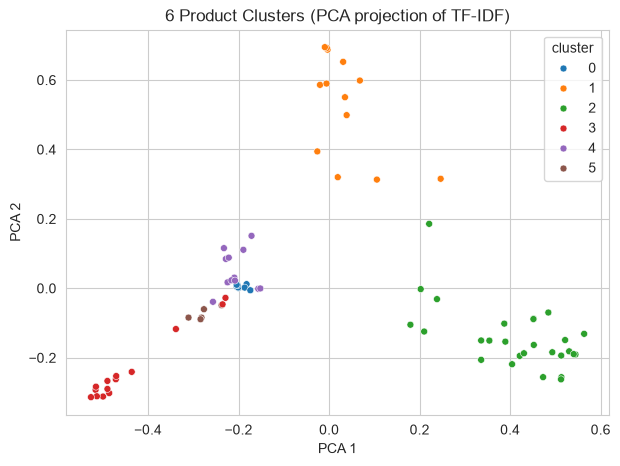

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=product_docs["cluster"], palette="tab10", legend="full", s=25
)
plt.title("6 Product Clusters (PCA projection of TF-IDF)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

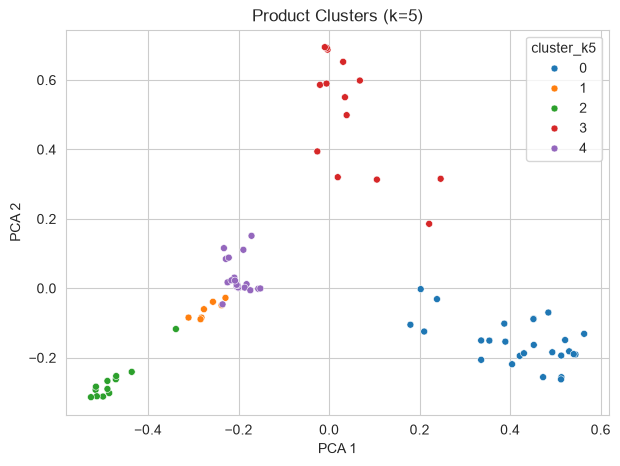

In [16]:
# For k=5
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=product_docs["cluster_k5"], palette="tab10", legend="full", s=25
)
plt.title("Product Clusters (k=5)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 10. Name the clusters

In [18]:
cluster_names = {
    0: "Household & Pet Supplies",
    1: "Kindle E-Readers",
    2: "Electronic Devices",
    3: "Smart Home Devices",
    4: "Electronic Device Accessories",
    5: "TV, Streaming & Media Players"
}

In [19]:
product_docs["cluster_name"] = product_docs["cluster"].map(cluster_names)
print(product_docs.shape)
product_docs.sample(10)

(79, 7)


,name,categories,primaryCategories,combined_text,cluster,cluster_k5,cluster_name
26,Certified Refurbished Amazon Echo,"Consumer Electronics,Amazon Echo,Smart Speaker...",Electronics,"Certified Refurbished Amazon Echo,Consumer Ele...",3,2,Smart Home Devices
43,AmazonBasics 11.6-Inch Laptop Sleeve,"Portable Computer Accessories,Bags, Cases & Sl...",Electronics,"AmazonBasics 11.6-Inch Laptop Sleeve,Portable ...",4,4,Electronic Device Accessories
28,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...","Computers/Tablets & Networking,Tablets & eBook...",Electronics,"Brand New Amazon Kindle Fire 16gb 7"" Ips Displ...",2,0,Electronic Devices
77,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...","Fire Tablets,Computers/Tablets & Networking,Wa...",Electronics,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",2,0,Electronic Devices
46,Amazon Kindle Replacement Power Adapter (Fits ...,"Computers & Accessories,Electronics,Amazon Dev...",Electronics,Amazon Kindle Replacement Power Adapter (Fits ...,4,4,Electronic Device Accessories
54,Amazon Echo Show - Black,"Amazon Echo,Virtual Assistant Speakers,Electro...",Electronics,"Amazon Echo Show - Black,Amazon Echo,Virtual A...",3,2,Smart Home Devices
14,Fire TV Stick Streaming Media Player Pair Kit,"Electronics,TVs Entertainment,Featured Brands,...",Electronics,"Fire TV Stick Streaming Media Player Pair Kit,...",5,1,"TV, Streaming & Media Players"
67,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...","Fire Tablets,Tablets,Computers/Tablets & Netwo...",Electronics,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",2,0,Electronic Devices
19,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...","Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",2,0,Electronic Devices
57,Amazon 9W PowerFast Official OEM USB Charger a...,"Computers & Accessories,Tablet & E-Reader Acce...",Electronics,Amazon 9W PowerFast Official OEM USB Charger a...,4,4,Electronic Device Accessories


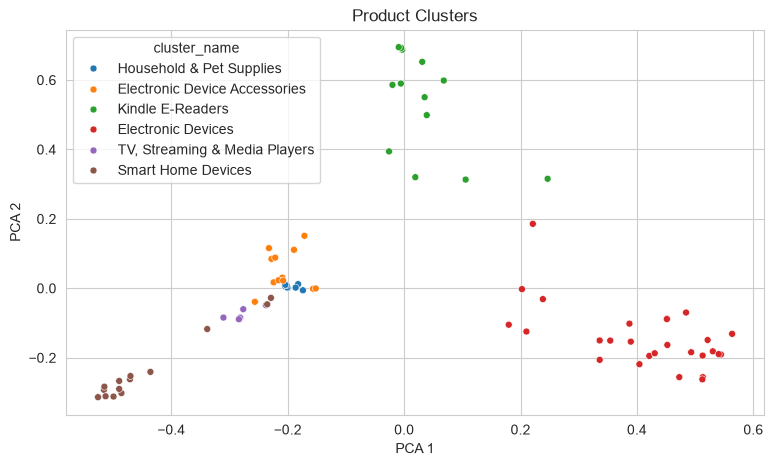

In [20]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=product_docs["cluster_name"], palette="tab10", legend="full", s=25
)
plt.title("Product Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [21]:
cluster_mapping = product_docs[["name", "cluster", "cluster_name"]].drop_duplicates()
print(cluster_mapping.shape)

df_original = df.merge(cluster_mapping, on="name", how="left")
print(df_original.shape)
df_original.sample(10)

(79, 3)
(30741, 12)


,asins,categories,id,name,primaryCategories,reviews.rating,reviews.text,reviews.title,clean_text,label,cluster,cluster_name
29136,B0189XYY0Q,"eBook Readers,Fire Tablets,Electronics Feature...",AVpidLjVilAPnD_xEVpI,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...","Office Supplies,Electronics",5,I would be happy to give it as Christmas gifts...,"Ease to use, does what I need!",i would be happy to give it as christmas gifts...,positive,2,Electronic Devices
21030,B018Y225IA,"Fire Tablets,Computers/Tablets & Networking,Ta...",AVpjEN4jLJeJML43rpUe,"Fire Tablet with Alexa, 7 Display, 16 GB, Blue...",Electronics,5,Great price works great I have no complaints a...,Great kindle,great price works great i have no complaints a...,positive,2,Electronic Devices
28700,B018Y23MNM,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",AVqVGWLKnnc1JgDc3jF1,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Electronics,4,This camera is a great addition to my home I r...,Awesome camera,this camera is a great addition to my home i r...,positive,2,Electronic Devices
3864,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,4,"I think they are great for the price, if you w...",good battery,"i think they are great for the price, if you w...",positive,0,Household & Pet Supplies
28476,B06XB29FPF,"Amazon Echo,Smart Home,Networking,Home & Tools...",AWMjT0WguC1rwyj_rFh3,Amazon - Echo Plus w/ Built-In Hub - Silver,"Electronics,Hardware",4,Needs some improvements on being able to answe...,Good,needs some improvements on being able to answe...,positive,3,Smart Home Devices
20778,B018Y225IA,"Fire Tablets,Computers/Tablets & Networking,Ta...",AVpjEN4jLJeJML43rpUe,"Fire Tablet with Alexa, 7 Display, 16 GB, Blue...",Electronics,5,I can use my tablet all time and your coneccti...,Excellent tablet forever,i can use my tablet all time and your coneccti...,positive,2,Electronic Devices
18496,B01J94YIT6,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",AVzYlGkFvKc47QAVeZRI,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",Electronics,5,Gave this as a Christmas gift to an older woma...,Couldnt go without it,gave this as a christmas gift to an older woma...,positive,2,Electronic Devices
16899,B018Y22BI4,"Fire Tablets,Computers/Tablets & Networking,Ta...",AVpgdkC8ilAPnD_xsvyi,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",Electronics,5,Using for Pandora in an office setting. Set up...,Easy Setup,using for pandora in an office setting. set up...,positive,2,Electronic Devices
21960,B018Y22C2Y,"Computers,Fire Tablets,Electronics Features,Co...",AVph0EeEilAPnD_x9myq,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Electronics,4,Good product for a young child to play with wi...,Good for kids,good product for a young child to play with wi...,positive,2,Electronic Devices
17297,B018Y22BI4,"Fire Tablets,Computers/Tablets & Networking,Ta...",AVpgdkC8ilAPnD_xsvyi,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",Electronics,5,Using the Kindle to read books and stream vide...,Great Kindle,using the kindle to read books and stream vide...,positive,2,Electronic Devices


## 11. Save results — clustered data + fitted models
Save the vectorizer and kmeans model with `joblib` so you can assign new/unseen products to a cluster later without refitting.

In [22]:
product_docs.to_csv("../data/processed/product_clusters.csv", index=False)
df_original.to_csv("../data/processed/reviews_with_clusters.csv", index=False)

joblib.dump(tfidf, "../models/tfidf_vectorizer.joblib")
joblib.dump(kmeans, "../models/kmeans_model.joblib")

print("Saved clustered data and models.")

Saved clustered data and models.


## 12. Predict the cluster for a new/unseen product
Load the saved vectorizer + model and transform new text the same way.

In [23]:
loaded_tfidf = joblib.load("../models/tfidf_vectorizer.joblib")
loaded_kmeans = joblib.load("../models/kmeans_model.joblib")

In [24]:
test_product = ["Maxpower Planet Double-Sided Dog Brush, Cat Brush for Long Hair, Undercoat Pet De-Matting Brush for Small to Large Dogs and Cats, Grooming Brush, Extra Wide, Blue"]
test_vec = loaded_tfidf.transform(test_product)
predicted_cluster = loaded_kmeans.predict(test_vec)

print("Predicted cluster:", cluster_names[predicted_cluster[0]])

Predicted cluster: Household & Pet Supplies


# Notes

- Initially, clustering was performed using only the **product name**. The results were reasonably good.
- Next, the **product name was combined with the product category**. This produced better and more informative clusters, with improved semantic separation between product groups.
- Clustering was first performed using the **raw text without any preprocessing or cleaning**, which produced good results. Simple text cleaning was then applied, but it did not lead to any significant change in the clustering results.
- Therefore, the final clustering approach uses the **combined product name and category as raw text**, without additional text cleaning or preprocessing.
- KMeans clustering was tested with **4, 5, and 6 clusters**.
- When comparing the **5-cluster and 6-cluster solutions**, the most notable difference was the separation of a previously mixed cluster. In the 5-cluster solution, one cluster contained both **computer accessories** and **pet/health supplies**, suggesting that these product categories were not being clearly separated.
- Increasing the number of clusters from **5 to 6** allowed KMeans to split this mixed cluster into two more meaningful groups, resulting in better semantic separation.
- Overall, the **6-cluster solution appears to be the most interpretable**, as it successfully separates **pet products from computer accessories** while keeping the other major product groups relatively intact.